<a href="https://colab.research.google.com/github/Comfortmoji/amr-ecoli-resistance-prediction/blob/main/Copy_of_amr_resistance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Kaggle_AMR_Dataset_v1.0.csv to Kaggle_AMR_Dataset_v1.0 (2).csv


In [ ]:
for col in df.columns:
    print(col)

Isolate_ID
Genome_Length_BP
GC_Content_Percent
gene_APH(3'')-Ib
gene_APH(3')-Ia
gene_APH(6)-Id
gene_CMY-59
gene_CRP
gene_CTX-M-14
gene_CTX-M-15
gene_CTX-M-27
gene_Escherichia_coli_acrA
gene_Escherichia_coli_ampC
gene_Escherichia_coli_ampC1_beta-lactamase
gene_Escherichia_coli_ampH
gene_Escherichia_coli_emrE
gene_Escherichia_coli_mdfA
gene_H-NS
gene_KPC-1
gene_MCR-1
gene_QnrS1
gene_aadA5
gene_acrB
gene_acrD
gene_acrE
gene_acrF
gene_acrS
gene_bacA
gene_baeR
gene_baeS
gene_cpxA
gene_dfrA17
gene_emrA
gene_emrB
gene_emrK
gene_emrR
gene_emrY
gene_eptA
gene_evgA
gene_evgS
gene_floR
gene_gadW
gene_gadX
gene_kdpE
gene_marA
gene_mdtA
gene_mdtB
gene_mdtC
gene_mdtE
gene_mdtF
gene_mdtG
gene_mdtH
gene_mdtM
gene_mdtN
gene_mdtO
gene_mdtP
gene_mphA
gene_mphB
gene_msbA
gene_pmrF
gene_sul1
gene_sul2
gene_tet(A)
gene_tet(B)
gene_tolC
gene_ugd
gene_yojI
class_acridine_dye
class_aminocoumarin
class_aminoglycoside
class_benzalkonium_chloride
class_carbapenem
class_cephalosporin
class_cephamycin
class_diamino

In [ ]:
df[['country', 'host', 'isolation_source', 'collection_year', 'total_amr_genes', 'total_resistance_classes']].head(10)

,country,host,isolation_source,collection_year,total_amr_genes,total_resistance_classes
0,NaN,NaN,NaN,NaN,45,23
1,NaN,NaN,NaN,NaN,47,23
2,NaN,NaN,NaN,NaN,51,25
3,NaN,NaN,NaN,NaN,51,24
4,NaN,NaN,NaN,NaN,46,23
5,NaN,NaN,NaN,NaN,46,23
6,NaN,NaN,NaN,NaN,46,23
7,NaN,NaN,NaN,NaN,46,23
8,NaN,NaN,NaN,NaN,46,23
9,NaN,NaN,NaN,NaN,45,23


In [ ]:
df[['country', 'host', 'isolation_source', 'collection_year']].isnull().sum()

,0
country,50
host,50
isolation_source,50
collection_year,50


In [ ]:
print(df.columns.tolist())

['Isolate_ID', 'Genome_Length_BP', 'GC_Content_Percent', "gene_APH(3'')-Ib", "gene_APH(3')-Ia", 'gene_APH(6)-Id', 'gene_CMY-59', 'gene_CRP', 'gene_CTX-M-14', 'gene_CTX-M-15', 'gene_CTX-M-27', 'gene_Escherichia_coli_acrA', 'gene_Escherichia_coli_ampC', 'gene_Escherichia_coli_ampC1_beta-lactamase', 'gene_Escherichia_coli_ampH', 'gene_Escherichia_coli_emrE', 'gene_Escherichia_coli_mdfA', 'gene_H-NS', 'gene_KPC-1', 'gene_MCR-1', 'gene_QnrS1', 'gene_aadA5', 'gene_acrB', 'gene_acrD', 'gene_acrE', 'gene_acrF', 'gene_acrS', 'gene_bacA', 'gene_baeR', 'gene_baeS', 'gene_cpxA', 'gene_dfrA17', 'gene_emrA', 'gene_emrB', 'gene_emrK', 'gene_emrR', 'gene_emrY', 'gene_eptA', 'gene_evgA', 'gene_evgS', 'gene_floR', 'gene_gadW', 'gene_gadX', 'gene_kdpE', 'gene_marA', 'gene_mdtA', 'gene_mdtB', 'gene_mdtC', 'gene_mdtE', 'gene_mdtF', 'gene_mdtG', 'gene_mdtH', 'gene_mdtM', 'gene_mdtN', 'gene_mdtO', 'gene_mdtP', 'gene_mphA', 'gene_mphB', 'gene_msbA', 'gene_pmrF', 'gene_sul1', 'gene_sul2', 'gene_tet(A)', 'gene_

In [ ]:

gene_cols = [col for col in df.columns if col.startswith('gene_')]
class_cols = [col for col in df.columns if col.startswith('class_')]

print("Top 10 most common genes:")
print(df[gene_cols].sum().sort_values(ascending=False).head(10))

print("\nTop 10 most common resistance classes:")
print(df[class_cols].sum().sort_values(ascending=False).head(10))

Top 10 most common genes:
gene_CRP                      50
gene_Escherichia_coli_ampH    50
gene_Escherichia_coli_ampC    50
gene_Escherichia_coli_acrA    50
gene_H-NS                     50
gene_emrK                     50
gene_emrB                     50
gene_emrA                     50
gene_bacA                     50
gene_baeR                     50
dtype: int64

Top 10 most common resistance classes:
class_acridine_dye       50
class_aminocoumarin      50
class_aminoglycoside     50
class_carbapenem         50
class_cephalosporin      50
class_fluoroquinolone    50
class_cephamycin         50
class_glycylcycline      50
class_fosfomycin         50
class_triclosan          50
dtype: int64


In [ ]:
gene_sums = df[gene_cols].sum().sort_values()
class_sums = df[class_cols].sum().sort_values()

print("Genes with the MOST variation (not always 0 or always 50):")
print(gene_sums[(gene_sums > 0) & (gene_sums < 50)])

print("\nClasses with variation:")
print(class_sums[(class_sums > 0) & (class_sums < 50)])

Genes with the MOST variation (not always 0 or always 50):
gene_CMY-59                                    1
gene_CTX-M-14                                  1
gene_CTX-M-27                                  1
gene_KPC-1                                     1
gene_aadA5                                     1
gene_dfrA17                                    1
gene_MCR-1                                     1
gene_APH(3')-Ia                                2
gene_QnrS1                                     2
gene_mphA                                      2
gene_tet(B)                                    2
gene_sul1                                      2
gene_CTX-M-15                                  4
gene_floR                                      8
gene_tet(A)                                    9
gene_APH(6)-Id                                10
gene_sul2                                     10
gene_APH(3'')-Ib                              10
gene_Escherichia_coli_ampC1_beta-lactamase    23
gene_mphB 

In [ ]:
print(df[['gene_sul1', 'gene_sul2', 'class_sulfonamide']])

    gene_sul1  gene_sul2  class_sulfonamide
0           0          0                  0
1           0          0                  0
2           1          0                  1
3           0          1                  1
4           0          0                  0
5           0          0                  0
6           0          0                  0
7           0          0                  0
8           0          0                  0
9           0          0                  0
10          0          1                  1
11          0          1                  1
12          0          1                  1
13          0          1                  1
14          0          1                  1
15          0          1                  1
16          0          1                  1
17          0          1                  1
18          0          0                  0
19          0          0                  0
20          0          0                  0
21          0          0        

In [ ]:
df[['ref_authors', 'ref_journal', 'ref_pubmed', 'organism']].head(10)

,ref_authors,ref_journal,ref_pubmed,organism
0,"Murakami,K., Ida,M., Kubota,H., Suzuki,Y., Miy...",Unpublished,NaN,Escherichia coli
1,"Kawano,K., Masaki,T., Kawaguchi,T. and Kuroda,M.","Antibiotics (Basel) 14 (4), 360 (2025)",40298502.0,Escherichia coli
2,"Koide,N., Matsuyama,R., Sugiyama,M., Yossapol,...",Unpublished,NaN,Escherichia coli
3,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli
4,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli
5,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli
6,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli
7,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli
8,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli
9,"Kakita,T., Ohnishi,M. and Nakamura,K.",Unpublished,NaN,Escherichia coli


In [ ]:
# Features: genome length, GC content, and all OTHER genes (excluding sul1/sul2 and the target itself)
feature_cols = ['Genome_Length_BP', 'GC_Content_Percent'] + [c for c in gene_cols if c not in ['gene_sul1', 'gene_sul2']]

X = df[feature_cols]
y = df['class_sulfonamide']

print(X.shape, y.shape)
print(y.value_counts())

(50, 64) (50,)
class_sulfonamide
0    39
1    11
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
loo = LeaveOneOut()

scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy')

print("Average accuracy:", scores.mean())
print("Number of correct predictions:", scores.sum(), "out of", len(scores))

Average accuracy: 0.94
Number of correct predictions: 47.0 out of 50


In [ ]:
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(15))

gene_APH(6)-Id                                0.206962
gene_APH(3'')-Ib                              0.172498
gene_floR                                     0.117326
gene_tet(A)                                   0.110983
gene_ugd                                      0.089387
Genome_Length_BP                              0.067456
GC_Content_Percent                            0.050439
gene_mphA                                     0.034354
gene_dfrA17                                   0.032490
gene_tet(B)                                   0.030557
gene_Escherichia_coli_ampC1_beta-lactamase    0.021338
gene_aadA5                                    0.017547
gene_CTX-M-27                                 0.015304
gene_Escherichia_coli_emrE                    0.008123
gene_CTX-M-14                                 0.007924
dtype: float64


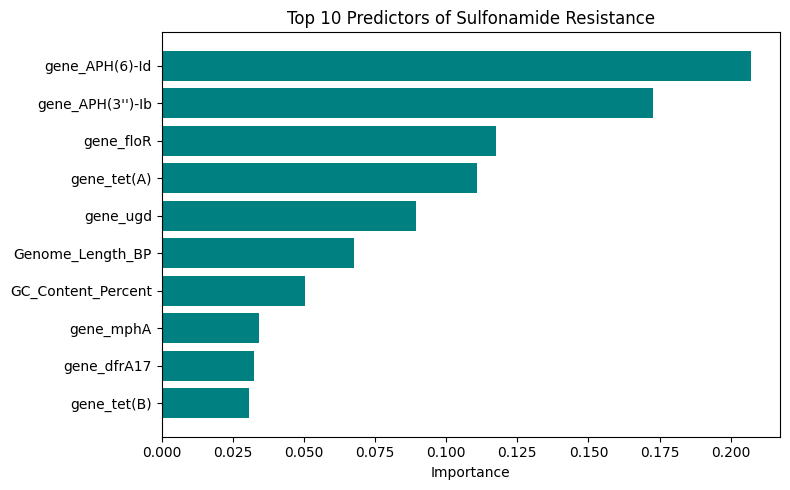

In [ ]:
import matplotlib.pyplot as plt

top_features = importances.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='teal')
plt.xlabel('Importance')
plt.title('Top 10 Predictors of Sulfonamide Resistance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

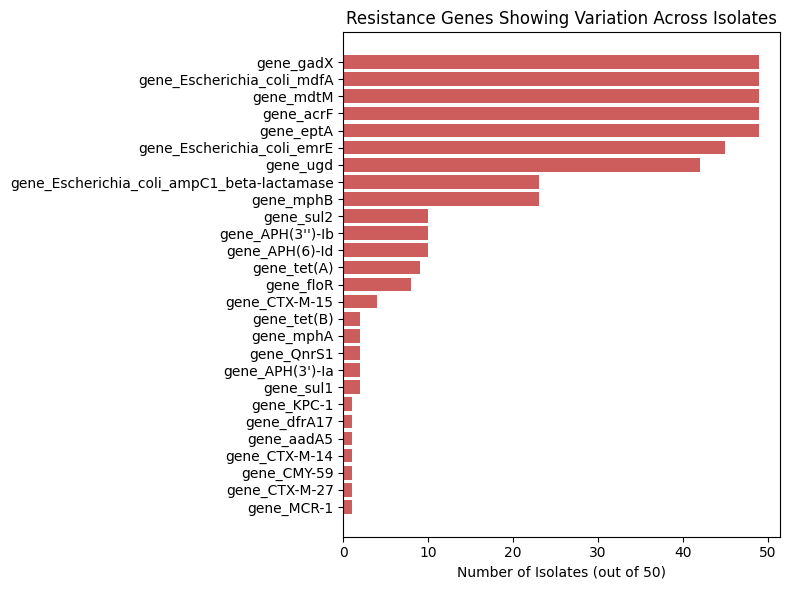

In [ ]:
variable_genes = gene_sums[(gene_sums > 0) & (gene_sums < 50)].sort_values(ascending=False)

plt.figure(figsize=(8,6))
plt.barh(variable_genes.index[::-1], variable_genes.values[::-1], color='indianred')
plt.xlabel('Number of Isolates (out of 50)')
plt.title('Resistance Genes Showing Variation Across Isolates')
plt.tight_layout()
plt.savefig('gene_variation.png', dpi=150)
plt.show()